<a href="https://colab.research.google.com/github/elizafhilip-png/TugasDataMining/blob/main/UTS/2304020183_Eliza%20Fhilip%20Sandjaya_UTS%20Data%20Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UTS DATA MINING**
## Prediksi Kualitas Wine Menggunakan Algoritma XGBoost

Nama   : Eliza Fhilip Sandjaya

NIM    : 2304020183  

Rombel : 4

# Pendahuluan

Data mining merupakan proses pengolahan data untuk menemukan pola atau informasi penting dari suatu kumpulan data. Salah satu metode dalam data mining adalah klasifikasi, yaitu metode yang digunakan untuk memprediksi kategori atau kelas tertentu berdasarkan data yang telah tersedia sebelumnya.

Pada penelitian ini digunakan dataset Wine Quality yang berisi karakteristik kimiawi dari sampel wine, seperti kadar alkohol, tingkat keasaman, kandungan sulfur, dan variabel lainnya. Variabel target yang diprediksi adalah quality, yaitu kualitas wine.

Tujuan dari penelitian ini adalah membangun model machine learning yang mampu memprediksi kualitas wine berdasarkan karakteristik kimiawi yang dimiliki. Algoritma yang digunakan pada penelitian ini adalah XGBoost karena memiliki performa yang baik dalam permasalahan klasifikasi.

In [58]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


# =====================================================
# 2. UPLOAD DATASET
# =====================================================

uploaded = files.upload()

Saving data_testing.csv to data_testing (4).csv
Saving data_training.csv to data_training (4).csv


Pada tahap ini dilakukan import berbagai library yang digunakan dalam proses analisis data mining. Library pandas dan numpy digunakan untuk pengolahan data, matplotlib dan seaborn digunakan untuk visualisasi data, sedangkan library scikit-learn dan XGBoost digunakan untuk membangun model machine learning klasifikasi. Selain itu dilakukan proses upload dataset training dan testing ke dalam Google Colab agar dapat digunakan pada tahap selanjutnya.

In [59]:
# =====================================================
# 3. MEMBACA DATASET
# =====================================================

train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

# =====================================================
# 4. MENAMPILKAN DATA
# =====================================================

print("===== DATA TRAINING =====")
display(train.head())

print("\n===== DATA TESTING =====")
display(test.head())

===== DATA TRAINING =====


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



===== DATA TESTING =====


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Dataset training dan dataset testing dibaca menggunakan fungsi read_csv(). Dataset training digunakan untuk melatih model karena memiliki variabel target yaitu quality, sedangkan dataset testing digunakan untuk proses prediksi kualitas wine. Setelah dataset dibaca, dilakukan penampilan beberapa baris data untuk melihat struktur awal dataset dan memastikan data berhasil dimuat dengan baik.

In [60]:
# =====================================================
# 5. INFORMASI DATASET
# =====================================================

print("\n===== INFO DATA TRAINING =====")
train.info()

print("\n===== STATISTIK DATA =====")
display(train.describe())


===== INFO DATA TRAINING =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

===== STATISTIK DATA =====


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Tahap ini dilakukan untuk mengetahui informasi umum mengenai dataset seperti jumlah baris, jumlah kolom, tipe data setiap variabel, dan struktur data secara keseluruhan. Berdasarkan hasil yang diperoleh, dataset terdiri dari beberapa fitur kimiawi wine seperti kadar alkohol, tingkat keasaman, sulfur dioksida, dan fitur lainnya yang digunakan untuk memprediksi kualitas wine.

In [61]:
# =====================================================
# 6. CEK MISSING VALUE
# =====================================================

print("\n===== MISSING VALUE TRAINING =====")
print(train.isnull().sum())

print("\n===== MISSING VALUE TESTING =====")
print(test.isnull().sum())


===== MISSING VALUE TRAINING =====
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

===== MISSING VALUE TESTING =====
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Pemeriksaan missing value dilakukan untuk mengetahui apakah terdapat data yang hilang pada dataset training maupun dataset testing. Berdasarkan hasil pemeriksaan, tidak ditemukan missing value pada seluruh variabel sehingga tidak diperlukan proses penanganan data hilang dan dataset dapat langsung digunakan untuk proses modeling.

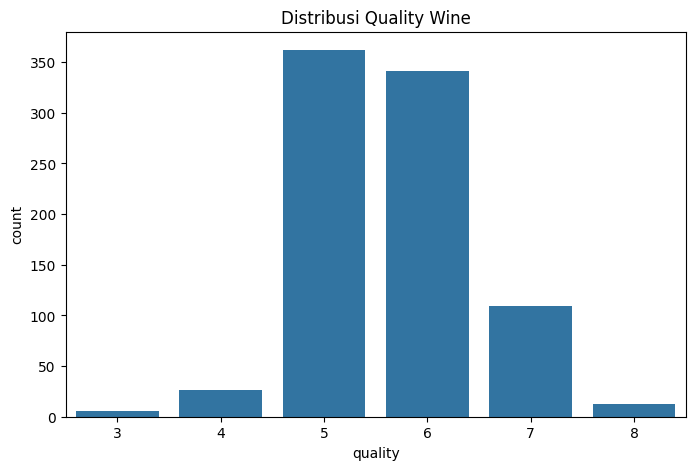

In [62]:
# =====================================================
# 7. VISUALISASI DISTRIBUSI QUALITY
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=train
)

plt.title('Distribusi Quality Wine')

plt.show()

Visualisasi distribusi quality dilakukan menggunakan diagram batang (countplot) untuk melihat jumlah data pada setiap kategori kualitas wine. Berdasarkan diagram batang yang diperoleh, terlihat bahwa kualitas wine dengan nilai 5 memiliki jumlah data paling banyak dibandingkan kategori lainnya. Hal ini menunjukkan bahwa sebagian besar sampel wine pada dataset memiliki kualitas sedang. Selain itu, distribusi data terlihat tidak sepenuhnya seimbang karena beberapa kategori quality memiliki jumlah data yang lebih sedikit dibandingkan kategori lainnya.

In [63]:
# =====================================================
# 8. MEMISAHKAN FITUR DAN TARGET
# =====================================================

X = train.drop(['quality', 'Id'], axis=1)

y = train['quality']

Pada tahap ini dilakukan pemisahan antara variabel fitur (X) dan variabel target (y). Variabel fitur terdiri dari seluruh karakteristik kimiawi wine, sedangkan variabel target adalah quality yang akan diprediksi oleh model. Kolom Id tidak digunakan dalam proses pelatihan model karena hanya berfungsi sebagai identitas data.

In [64]:
# =====================================================
# 9. ENCODING TARGET
# =====================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

Encoding target dilakukan menggunakan LabelEncoder() untuk mengubah label kategori pada variabel quality menjadi bentuk numerik yang dapat diproses oleh algoritma XGBoost. Proses encoding ini membantu model machine learning dalam memahami data target secara lebih efektif.

In [65]:
# =====================================================
# 10. SPLIT DATA
# =====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

Dataset training dibagi menjadi data training dan data validasi dengan perbandingan 80:20 menggunakan train_test_split(). Data training digunakan untuk melatih model, sedangkan data validasi digunakan untuk menguji performa model sebelum diterapkan pada data testing.

In [66]:
# =====================================================
# 11. FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

Feature scaling dilakukan menggunakan StandardScaler() untuk menyamakan skala antar fitur. Proses ini penting karena setiap fitur memiliki rentang nilai yang berbeda-beda. Dengan melakukan scaling, performa model dapat menjadi lebih optimal dalam proses pelatihan dan prediksi.

In [67]:
# =====================================================
# 12. MEMBUAT MODEL XGBOOST
# =====================================================

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    objective='multi:softmax',
    random_state=42
)

Pada penelitian ini digunakan algoritma XGBoost untuk melakukan klasifikasi kualitas wine. XGBoost dipilih karena memiliki performa yang baik dalam menangani data klasifikasi dan mampu menghasilkan akurasi yang cukup tinggi dibandingkan beberapa algoritma lainnya.

In [68]:
# =====================================================
# 13. TRAINING MODEL
# =====================================================

model.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

Setelah model XGBoost dibuat, dilakukan proses training menggunakan data training yang telah dipersiapkan sebelumnya. Pada tahap ini model mempelajari pola hubungan antara karakteristik kimiawi wine dengan kualitas wine sehingga model dapat digunakan untuk melakukan prediksi pada data baru.

In [69]:
# =====================================================
# 14. PREDIKSI DATA VALIDASI
# =====================================================

pred_val = model.predict(X_val_scaled)

# =====================================================
# 15. EVALUASI MODEL
# =====================================================

accuracy = accuracy_score(
    y_val,
    pred_val
)

print("\n===== HASIL AKURASI =====")
print("Accuracy :", accuracy)


===== HASIL AKURASI =====
Accuracy : 0.6162790697674418


Model yang telah dilatih kemudian digunakan untuk memprediksi data validasi. Evaluasi model dilakukan menggunakan metrik accuracy untuk mengetahui tingkat ketepatan prediksi model. Berdasarkan hasil evaluasi diperoleh nilai accuracy sebesar 0.6162790697674418 atau sekitar 61,6%. Hal ini menunjukkan bahwa model mampu memprediksi kualitas wine dengan cukup baik berdasarkan fitur-fitur kimiawi yang tersedia.

In [70]:
# =====================================================
# 16. CLASSIFICATION REPORT
# =====================================================

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_val,
        pred_val
    )
)


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.68      0.79      0.73        73
           3       0.57      0.60      0.59        68
           4       0.46      0.27      0.34        22
           5       1.00      0.33      0.50         3

    accuracy                           0.62       172
   macro avg       0.45      0.33      0.36       172
weighted avg       0.59      0.62      0.60       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report digunakan untuk melihat performa model secara lebih rinci pada setiap kelas quality. Laporan ini menampilkan nilai precision, recall, f1-score, dan support. Dari hasil tersebut dapat diketahui bahwa performa model pada beberapa kelas lebih baik dibandingkan kelas lainnya, tergantung jumlah data dan karakteristik masing-masing kelas.

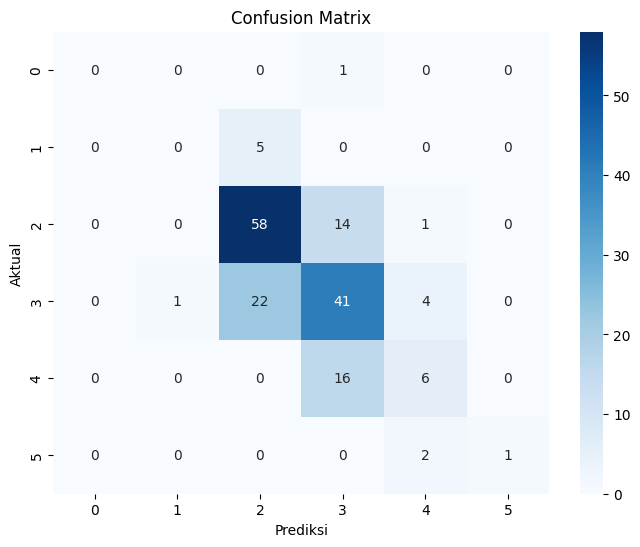

In [71]:
# =====================================================
# 17. CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_val,
    pred_val
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Prediksi')

plt.ylabel('Aktual')

plt.show()

Confusion matrix digunakan untuk melihat perbandingan antara hasil prediksi model dan data aktual. Berdasarkan confusion matrix yang diperoleh, sebagian besar data berhasil diprediksi dengan benar oleh model. Namun masih terdapat beberapa kesalahan prediksi pada kelas tertentu karena adanya kemiripan karakteristik antar kualitas wine.

In [72]:
# =====================================================
# 18. FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")

display(importance)

# =====================================================
# 19. PREPROCESSING DATA TESTING
# =====================================================

X_test = test.drop('Id', axis=1)

X_test_scaled = scaler.transform(X_test)


===== FEATURE IMPORTANCE =====


,Feature,Importance
10,alcohol,0.142560
9,sulphates,0.118219
1,volatile acidity,0.108243
6,total sulfur dioxide,0.088177
4,chlorides,0.084192
2,citric acid,0.083341
0,fixed acidity,0.080125
5,free sulfur dioxide,0.077109
7,density,0.076261
8,pH,0.073213


Feature importance digunakan untuk mengetahui fitur-fitur yang paling berpengaruh dalam menentukan kualitas wine. Dari hasil yang diperoleh, beberapa fitur memiliki pengaruh yang lebih besar dibandingkan fitur lainnya terhadap hasil prediksi model. Setelah itu dilakukan preprocessing pada data testing dengan menerapkan scaling yang sama seperti pada data training agar data testing memiliki skala yang konsisten sebelum dilakukan prediksi.

In [73]:
# =====================================================
# 20. PREDIKSI DATA TESTING
# =====================================================

hasil_prediksi = model.predict(
    X_test_scaled
)

# =====================================================
# 21. KEMBALIKAN LABEL ASLI
# =====================================================

hasil_prediksi = label_encoder.inverse_transform(
    hasil_prediksi
)

# =====================================================
# 22. MEMBUAT FILE SUBMISSION
# =====================================================

submission = pd.DataFrame({
    'Id': test['Id'],
    'Quality': hasil_prediksi
})

# =====================================================
# 23. MENAMPILKAN HASIL PREDIKSI
# =====================================================

print("\n===== HASIL PREDIKSI =====")

display(submission.head())


===== HASIL PREDIKSI =====


,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


Model yang telah dilatih digunakan untuk memprediksi kualitas wine pada dataset testing. Hasil prediksi yang sebelumnya berbentuk label numerik hasil encoding kemudian dikembalikan ke label aslinya menggunakan inverse_transform(). Selanjutnya dibuat file submission yang berisi dua kolom yaitu Id dan Quality.

Berdasarkan hasil prediksi yang diperoleh, beberapa data diprediksi memiliki kualitas wine sebesar 5, sedangkan terdapat juga data yang diprediksi memiliki kualitas 6. Sebagai contoh, data dengan Id 1514 diprediksi memiliki kualitas wine sebesar 6, sedangkan data lainnya seperti Id 222, 417, 754, dan 516 diprediksi memiliki kualitas sebesar 5. Hal ini menunjukkan bahwa model berhasil memberikan variasi prediksi berdasarkan karakteristik kimiawi masing-masing wine.

In [76]:
# =====================================================
# 24. MENYIMPAN FILE CSV
# =====================================================

submission.to_csv(
    'hasilprediksi_183.csv',
    index=False
)

print("\nFILE CSV BERHASIL DISIMPAN!")

# =====================================================
# 25. DOWNLOAD FILE CSV
# =====================================================

files.download(
    'hasilprediksi_183.csv'
)


FILE CSV BERHASIL DISIMPAN!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tahap terakhir adalah menyimpan hasil prediksi ke dalam file CSV menggunakan fungsi to_csv(). File disimpan dengan format yang sesuai ketentuan pengumpulan, yaitu hanya berisi dua kolom: Id dan Quality. File CSV ini kemudian digunakan sebagai hasil akhir prediksi untuk dikumpulkan.